In [ ]:
# ============================================================
# LangGraph Multi-Agent Routing Demo v6 - OpenAI SDK
# ------------------------------------------------------------
# 핵심 의도
# 1) General 질문은 OpenAI LLM이 직접 응답한다.
# 2) DB 계열 질문은 실제 DB에 접속하지 않는다.
# 3) 대신 mock_data/*.json 파일을 "DB/RAG/GraphDB 조회 결과"처럼 읽는다.
# 4) 읽어온 mock 결과를 LLM 프롬프트에 context로 넣어 증강 응답을 생성한다.
# 5) 즉, mock 파일은 근거 데이터이고, 최종 답변은 OpenAI LLM이 생성한다.
# ============================================================



# 1. 기본 패키지 설치



In [1]:
# Google Colab에서 실행할 때만 실행하세요.
# LangChain / langchain-openai 충돌을 피하기 위해 설치하지 않습니다.
# LangGraph + OpenAI SDK만 사용합니다.

%pip uninstall -y langchain langchain-openai
%pip install -qU langgraph openai


Found existing installation: langchain 1.3.6
Uninstalling langchain-1.3.6:
  Successfully uninstalled langchain-1.3.6
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.2/246.2 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.9/554.9 kB 34.0 MB/s eta 0:00:00


# 2. API Key 설정



In [2]:
import os
import json
from pathlib import Path
from typing import Dict, Any, Literal
from typing_extensions import TypedDict, Annotated

from openai import OpenAI
from langchain_core.messages import AnyMessage, HumanMessage, SystemMessage, AIMessage

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver

# 개인 실습/시연용 하드코딩 방식
# 공유/제출 전에는 반드시 키를 제거하세요.
os.environ["OPENAI_API_KEY"] = "sk-proj-TEST-API-KEY"

print("OPENAI_API_KEY 설정 완료")


OPENAI_API_KEY 설정 완료


# 3. LLM Model 정의



In [3]:
MODEL_NAME = "gpt-4.1-nano"  # 필요하면 여기만 바꾸면 됩니다.

client = OpenAI()

def call_llm(system_prompt: str, user_prompt: str, temperature: float = 0.2) -> str:
    """
    OpenAI SDK를 직접 호출하는 공통 LLM 함수입니다.

    """
    response = client.chat.completions.create(
        model=MODEL_NAME,
        temperature=temperature,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ],
    )
    return response.choices[0].message.content

print(f"LLM model = {MODEL_NAME}")


LLM model = gpt-4.1-nano


In [4]:
# v6 검증: OpenAI SDK call_llm 함수 사용 여부 확인
print("call_llm ready =", callable(call_llm))
print("MODEL_NAME =", MODEL_NAME)


call_llm ready = True
MODEL_NAME = gpt-4.1-nano


# 4.1. Google Drive 마운트



In [6]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [7]:
from pathlib import Path
MOCK_DATA_DIR = Path("/content/drive/MyDrive/Colab Notebooks/mock_data")
validate_mock_files()

mock 파일 확인
- stock  : /content/drive/MyDrive/Colab Notebooks/mock_data/postgresql_stock_mock.json -> OK
- news   : /content/drive/MyDrive/Colab Notebooks/mock_data/pgvector_news_mock.json -> OK
- graph  : /content/drive/MyDrive/Colab Notebooks/mock_data/neo4j_relation_mock.json -> OK
- general: /content/drive/MyDrive/Colab Notebooks/mock_data/general_llm_mock.json -> OK


In [14]:
!pwd
!ls -al
!ls -al "/content/drive/MyDrive/Colab Notebooks"
!ls -al "/content/drive/MyDrive/Colab Notebooks/mock_data"

/content
total 20
drwxr-xr-x 1 root root 4096 Jun 15 13:15 .
drwxr-xr-x 1 root root 4096 Jun 15 12:41 ..
drwxr-xr-x 4 root root 4096 Jun  4 13:32 .config
drwx------ 5 root root 4096 Jun 15 13:15 drive
drwxr-xr-x 1 root root 4096 Jun  4 13:32 sample_data
total 228
-rw------- 1 root root 191683 Jun 15 13:11 langgraph_multi_agent_colab_run_v5.ipynb
-rw------- 1 root root  37210 Jun 15 13:17 langgraph_multi_agent_colab_run_v6_openai_sdk.ipynb
drwx------ 2 root root   4096 Jun 15 12:30 mock_data
total 7
-rw------- 1 root root  200 Jun 15 11:28 general_llm_mock.json
-rw------- 1 root root 1789 Jun 15 11:28 neo4j_relation_mock.json
-rw------- 1 root root 1806 Jun 15 11:28 pgvector_news_mock.json
-rw------- 1 root root 2151 Jun 15 11:28 postgresql_stock_mock.json


# 4.2. mock (Json) 샘플 파일 경로

In [15]:
# mock_data 디렉터리는 이 노트북/소스와 같은 위치에 있다고 가정한다.
# Colab에서는 왼쪽 파일 패널에 mock_data 폴더를 업로드하거나,
# ZIP 패키지를 풀어서 같은 디렉터리 구조를 유지하면 된다.
# MOCK_DATA_DIR = Path("./mock_data")
MOCK_DATA_DIR = Path("/content/drive/MyDrive/Colab Notebooks/mock_data")

MOCK_FILES = {
    "stock": "postgresql_stock_mock.json",
    "news": "pgvector_news_mock.json",
    "graph": "neo4j_relation_mock.json",
    "general": "general_llm_mock.json",  # 일반 질문 응답에는 사용하지 않음. 설명용 파일.
}


def load_mock_json(mock_key: str) -> Dict[str, Any]:
    """
    mock_data/*.json 파일을 읽는다.

    이 함수가 현재 데모에서 '가짜 DB 조회' 경계다.
    나중에는 이 함수 또는 각 Agent 내부를 실제 PostgreSQL / pgvector / Neo4j 호출로 교체하면 된다.
    """
    if mock_key not in MOCK_FILES:
        raise ValueError(f"Unknown mock_key: {mock_key}")

    file_path = MOCK_DATA_DIR / MOCK_FILES[mock_key]
    if not file_path.exists():
        raise FileNotFoundError(
            f"mock 파일이 없습니다: {file_path}\n"
            f"mock_data 폴더와 JSON 파일을 현재 실행 위치에 배치하세요."
        )

    with file_path.open("r", encoding="utf-8") as f:
        return json.load(f)


def validate_mock_files() -> None:
    """데모 실행 전에 mock 파일이 있는지 확인한다."""
    print("mock 파일 확인")
    for key, file_name in MOCK_FILES.items():
        file_path = MOCK_DATA_DIR / file_name
        status = "OK" if file_path.exists() else "MISSING"
        print(f"- {key:7s}: {file_path} -> {status}")


validate_mock_files()



mock 파일 확인
- stock  : /content/drive/MyDrive/Colab Notebooks/mock_data/postgresql_stock_mock.json -> OK
- news   : /content/drive/MyDrive/Colab Notebooks/mock_data/pgvector_news_mock.json -> OK
- graph  : /content/drive/MyDrive/Colab Notebooks/mock_data/neo4j_relation_mock.json -> OK
- general: /content/drive/MyDrive/Colab Notebooks/mock_data/general_llm_mock.json -> OK


# 5. State 정의



In [34]:
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage, SystemMessage

# 1. RouteName
# 허용되는 라우팅 이름을 타입으로 정의한 것.
#   stock_sql       → 주가/주식
#   news_vector     → 뉴스/RAG
#   graph_relation  → 관계/GraphDB
#   general_llm     → 일반 질문
#   graphrag        → 복합질의

RouteName = Literal[
    "stock_sql",
    "news_vector",
    "graph_relation",
    "general_llm",
    "graphrag",
]

# 2. ALLOWED_ROUTES
# - Router Agent가 반환한 route 값이 정상인지 검증하기 위한 실제 허용 목록이다.
# - LLM이 오타나 이상한 값을 반환할 수 있으므로, 이 set으로 방어한다.
ALLOWED_ROUTES = {
    "stock_sql",
    "news_vector",
    "graph_relation",
    "general_llm",
    "graphrag",
}


# 3. merge_agent_outputs
# - LangGraph State의 agent_outputs 값을 누적 병합하기 위한 함수다.
# - 여러 Agent가 각각 결과를 추가할 때 기존 결과가 사라지지 않게 한다.
# - 예: {"stock": ...} + {"news": ...} → {"stock": ..., "news": ...}
def merge_agent_outputs(left: Dict[str, Any] | None, right: Dict[str, Any] | None) -> Dict[str, Any]:
    """LangGraph State에서 agent_outputs dict를 누적 병합한다."""
    merged = dict(left or {})
    merged.update(right or {})
    return merged

# 4. ChatState
# - LangGraph의 각 Node 사이에서 전달되는 공통 상태 객체다.
# - Router Agent, DB Agent, GraphRAG Orchestrator가 모두 이 State를 읽고 수정한다.
class ChatState(TypedDict, total=False):

    # LangGraph 대화 메시지 누적용
    # add_messages를 사용하면 새 메시지가 기존 messages에 자동으로 누적된다.
    messages: Annotated[list[AnyMessage], add_messages]

    # 사용자 원문 질문
    user_question: str

    # router_agent가 선택한 route 값
    # 예: stock_sql, news_vector, graph_relation, general_llm, graphrag
    route: str

    # 각 Agent의 중간 결과 저장용 dict
    # merge_agent_outputs를 통해 여러 Agent 결과가 누적된다.
    agent_outputs: Annotated[Dict[str, Any], merge_agent_outputs]

    # 최종 답변
        # 사용자에게 최종 반환할 답변

    final_answer: str




# 6. 공통 Helper 함수 정의


In [35]:
# 공통 유틸 함수 정의 셀
# Agent들이 공통으로 쓰는 “보조 함수 묶음”
#     get_user_question()        → State에서 사용자 질문 꺼냄
#     normalize_route()          → Router 결과값 보정
#     context_to_text()          → JSON mock 데이터를 LLM prompt용 문자열로 변환
#     invoke_llm_with_context()  → mock 데이터를 LLM에 넣어 증강 답변 생성


def get_user_question(state: ChatState) -> str:
    """State에서 사용자 질문을 안전하게 추출한다."""
    if state.get("user_question"):
        return state["user_question"]

    for msg in reversed(state.get("messages", [])):
        if isinstance(msg, HumanMessage):
            return msg.content

    return ""


def normalize_route(raw_text: str) -> str:
    """
    LLM이 route만 깔끔하게 반환하지 않을 수 있으므로 보정한다.
    허용되지 않은 값이면 general_llm으로 fallback 한다.
    """
    text = (raw_text or "").strip().lower()

    # 가장 이상적인 경우: route 하나만 반환
    if text in ALLOWED_ROUTES:
        return text

    # 문장 안에 route가 섞여 들어온 경우 방어
    for route in ALLOWED_ROUTES:
        if route in text:
            return route

    return "general_llm"


def context_to_text(context: Dict[str, Any]) -> str:
    """LLM prompt에 넣기 좋게 JSON context를 문자열로 변환한다."""
    return json.dumps(context, ensure_ascii=False, indent=2)


def invoke_llm_with_context(
    *,
    agent_name: str,
    user_question: str,
    context: Dict[str, Any],
    task_instruction: str,
) -> str:
    """
    DB/RAG/GraphDB mock 조회 결과를 LLM에 넣어 증강 답변을 생성한다.

    중요:
    - 이 함수는 mock 데이터를 그대로 출력하지 않는다.
    - mock 데이터를 근거 context로 사용해서 OpenAI LLM이 답변을 생성한다.
    """
    system_prompt = f"""
너는 {agent_name} 역할을 수행하는 데이터 기반 응답 에이전트다.
아래 원칙을 반드시 따른다.

1. 제공된 CONTEXT는 실제 DB/RAG/GraphDB 조회 결과를 흉내 낸 mock 데이터다.
2. 지금은 실제 DB에 접속하지 않는다.
3. 답변은 반드시 CONTEXT에 근거해서 작성한다.
4. CONTEXT에 없는 사실은 단정하지 말고, 'mock 데이터 기준'이라고 표현한다.
5. 사용자가 보기 쉽게 한국어로 답변한다.
6. 너무 길게 쓰지 말고, 시연용으로 흐름이 잘 보이게 작성한다.
""".strip()

    human_prompt = f"""
[사용자 질문]
{user_question}

[Agent 작업 지시]
{task_instruction}

[CONTEXT: mock 조회/검색 결과]
{context_to_text(context)}

위 CONTEXT를 근거로 최종 답변을 생성해라.
""".strip()

    return call_llm(
        system_prompt=system_prompt,
        user_prompt=human_prompt,
        temperature=0.2,
    )




# 7. 검증

In [37]:
# 검증
#  1. 함수들이 정상 정의되었는지

#  2. get_user_question 이 State (ChatState) 에서 질문을 잘 꺼내는지
#  3. normalize_route 가 이상한 route를 general_llm으로 보정하는지
#  4. context_to_text 가 mock JSON을 문자열로 잘 바꾸는지 → dict/json 데이터를 LLM prompt에 넣을 문자열로 잘 바꾸는지 확인

#  5. invoke_llm_with_context 가 mock context를 LLM에 넣어 답변을 생성하는지


print("유틸 함수 정의 확인")

required_functions = [
    "get_user_question",
    "normalize_route",
    "context_to_text",
    "invoke_llm_with_context",
]

for fn in required_functions:
    print(f"- {fn} exists:", fn in globals(), "/ callable:", callable(globals().get(fn)))

required_globals = [
    "ChatState",
    "HumanMessage",
    "ALLOWED_ROUTES",
    "json",
    "call_llm",
]

for name in required_globals:
    print(f"- {name} exists:", name in globals())

유틸 함수 정의 확인
- get_user_question exists: True / callable: True
- normalize_route exists: True / callable: True
- context_to_text exists: True / callable: True
- invoke_llm_with_context exists: True / callable: True
- ChatState exists: True
- HumanMessage exists: True
- ALLOWED_ROUTES exists: True
- json exists: True
- call_llm exists: True


In [38]:
# 검증
#  1. 함수들이 정상 정의되었는지

#  2. get_user_question 이 State (ChatState) 에서 질문을 잘 꺼내는지
#  3. normalize_route 가 이상한 route를 general_llm으로 보정하는지
#  4. context_to_text 가 mock JSON을 문자열로 잘 바꾸는지 → dict/json 데이터를 LLM prompt에 넣을 문자열로 잘 바꾸는지 확인

#  5. invoke_llm_with_context 가 mock context를 LLM에 넣어 답변을 생성하는지



# 함수별 동작 검증

# 1. get_user_question 검증
test_state_1: ChatState = {
    "user_question": "애플 최근 주가 알려줘",
    "messages": [],
}

test_state_2: ChatState = {
    "messages": [HumanMessage(content="엔비디아 뉴스 요약해줘")]
}

print("get_user_question test 1:", get_user_question(test_state_1))
print("get_user_question test 2:", get_user_question(test_state_2))


# 2. normalize_route 검증
print("normalize_route test 1:", normalize_route("stock_sql"))
print("normalize_route test 2:", normalize_route("route is news_vector"))
print("normalize_route test 3:", normalize_route("이상한값"))


# 3. context_to_text 검증
sample_context = {
    "source": "mock PostgreSQL",
    "company": "Apple",
    "price": 195.32,
}

print("context_to_text test:")
print(context_to_text(sample_context))

get_user_question test 1: 애플 최근 주가 알려줘
get_user_question test 2: 엔비디아 뉴스 요약해줘
normalize_route test 1: stock_sql
normalize_route test 2: news_vector
normalize_route test 3: general_llm
context_to_text test:
{
  "source": "mock PostgreSQL",
  "company": "Apple",
  "price": 195.32
}


In [39]:
# 검증
#  1. 함수들이 정상 정의되었는지

#  2. get_user_question 이 State (ChatState) 에서 질문을 잘 꺼내는지
#  3. normalize_route 가 이상한 route를 general_llm으로 보정하는지
#  4. context_to_text 가 mock JSON을 문자열로 잘 바꾸는지 → dict/json 데이터를 LLM prompt에 넣을 문자열로 잘 바꾸는지 확인

#  5. invoke_llm_with_context 가 mock context를 LLM에 넣어 답변을 생성하는지
# 실제 DB 테이블 없음 >> mock_data/postgresql_stock_mock.json 읽음 >> 그 JSON을 PostgreSQL 조회 결과처럼 간주 >> LLM에 context로 전달 >> LLM이 답변 생성


sample_answer = invoke_llm_with_context(
    agent_name="PostgreSQL NL2SQL Agent",
    user_question="애플 최근 주가 알려줘",
    context={
        "mock_source": "PostgreSQL",
        "generated_sql": "SELECT trade_date, close_price, volume FROM stock_prices WHERE company_name = 'Apple' ORDER BY trade_date DESC LIMIT 5;",
        "rows": [
            {"trade_date": "2026-06-14", "close_price": 195.32, "volume": 54210000},
            {"trade_date": "2026-06-13", "close_price": 193.10, "volume": 49800000},
        ],
    },
    task_instruction="mock PostgreSQL 조회 결과를 바탕으로 주가 현황을 요약한다.",
)

print(sample_answer)

애플의 최근 주가는 2026년 6월 14일 기준으로 195.32달러입니다.


# 8. Router 함수 정의



In [18]:
def router_agent(state: ChatState) -> ChatState:
    """
    사용자 질문을 보고 어느 Agent로 보낼지 결정한다.
    실제 LLM을 사용해서 route를 분류한다.
    """
    user_question = get_user_question(state)

    system_prompt = """
너는 LangGraph 멀티 에이전트 시스템의 router agent다.
사용자 질문을 보고 아래 route 중 정확히 하나만 반환해라.
다른 설명은 절대 쓰지 말고 route 문자열만 출력해라.

허용 route:
- stock_sql
- news_vector
- graph_relation
- general_llm
- graphrag

분류 기준:
- 주가, 주식, 가격, 시세, PER, 거래량, 상승률, 하락률 → stock_sql
- 뉴스, 기사, 최근 소식, 보도자료, 이슈 → news_vector
- 관계, 연결, 영향, 기업 간 관계, 이벤트 관계 → graph_relation
- 주가 + 뉴스 + 관계처럼 여러 정보가 동시에 필요 → graphrag
- 그 외 일반 질문 → general_llm
""".strip()

    raw_route = call_llm(
        system_prompt=system_prompt,
        user_prompt=user_question,
        temperature=0.0,
    )

    route = normalize_route(raw_route)

    print(f"[router_agent] question = {user_question}")
    print(f"[router_agent] raw route = {raw_route}")
    print(f"[router_agent] normalized route = {route}")

    return {
        "user_question": user_question,
        "route": route,
        "agent_outputs": {
            "router": {
                "raw_route": raw_route,
                "normalized_route": route,
            }
        },
    }


def route_to_node(state: ChatState) -> str:
    """router_agent 결과를 실제 LangGraph node 이름으로 변환한다."""
    route = state.get("route", "general_llm")

    mapping = {
        "stock_sql": "stock_sql_agent",
        "news_vector": "news_vector_agent",
        "graph_relation": "graph_relation_agent",
        "general_llm": "general_llm_agent",
        "graphrag": "graphrag_orchestrator",
    }
    return mapping.get(route, "general_llm_agent")




# 9. Agent Node 함수 정의



In [19]:
def stock_sql_agent(state: ChatState) -> ChatState:
    """
    PostgreSQL + NL2SQL Agent 역할.

    현재는 실제 PostgreSQL에 접속하지 않는다.
    postgresql_stock_mock.json 파일을 읽어 'DB 조회 결과'처럼 사용하고,
    그 결과를 LLM에 전달해 최종 답변을 생성한다.

    TODO:
    - load_mock_json("stock") 부분을 실제 PostgreSQL 접속 + SQL 실행으로 교체한다.
    """
    user_question = get_user_question(state)
    context = load_mock_json("stock")

    task_instruction = """
사용자 질문을 주식가격/NL2SQL 관점에서 답변한다.
CONTEXT 안의 schema_hint, nl2sql_examples, rows를 활용한다.
가능하면 생성 SQL 예시, mock 조회 결과 요약, 해석을 포함한다.
""".strip()

    answer = invoke_llm_with_context(
        agent_name="PostgreSQL NL2SQL Agent",
        user_question=user_question,
        context=context,
        task_instruction=task_instruction,
    )

    return {
        "final_answer": answer,
        "messages": [AIMessage(content=answer)],
        "agent_outputs": {
            "stock_sql_agent": {
                "context_file": MOCK_FILES["stock"],
                "llm_augmented": True,
                "context_summary": "PostgreSQL mock 조회 결과를 LLM context로 전달함",
                "answer": answer,
            }
        },
    }


def news_vector_agent(state: ChatState) -> ChatState:
    """
    pgvector / VectorDB RAG Agent 역할.

    현재는 실제 pgvector에 접속하지 않는다.
    pgvector_news_mock.json 파일을 읽어 'Vector Search 검색 결과'처럼 사용하고,
    그 결과를 LLM에 전달해 최종 답변을 생성한다.

    TODO:
    - load_mock_json("news") 부분을 실제 embedding + pgvector similarity search로 교체한다.
    """
    user_question = get_user_question(state)
    context = load_mock_json("news")

    task_instruction = """
사용자 질문을 뉴스 RAG 관점에서 답변한다.
CONTEXT 안의 retrieval_query_template과 chunks를 활용한다.
검색된 뉴스 chunk를 근거로 요약하고, 관련도 score가 있다는 점을 반영한다.
""".strip()

    answer = invoke_llm_with_context(
        agent_name="pgvector RAG Agent",
        user_question=user_question,
        context=context,
        task_instruction=task_instruction,
    )

    return {
        "final_answer": answer,
        "messages": [AIMessage(content=answer)],
        "agent_outputs": {
            "news_vector_agent": {
                "context_file": MOCK_FILES["news"],
                "llm_augmented": True,
                "context_summary": "pgvector mock 검색 결과를 LLM context로 전달함",
                "answer": answer,
            }
        },
    }


def graph_relation_agent(state: ChatState) -> ChatState:
    """
    Neo4j GraphDB Agent 역할.

    현재는 실제 Neo4j에 접속하지 않는다.
    neo4j_relation_mock.json 파일을 읽어 'Graph Traversal 조회 결과'처럼 사용하고,
    그 결과를 LLM에 전달해 최종 답변을 생성한다.

    TODO:
    - load_mock_json("graph") 부분을 실제 Neo4j driver + Cypher 실행으로 교체한다.
    """
    user_question = get_user_question(state)
    context = load_mock_json("graph")

    task_instruction = """
사용자 질문을 기업/뉴스/이벤트 관계 관점에서 답변한다.
CONTEXT 안의 cypher_examples와 relations를 활용한다.
그래프의 node-edge-node 관계가 드러나도록 설명한다.
""".strip()

    answer = invoke_llm_with_context(
        agent_name="Neo4j Graph Agent",
        user_question=user_question,
        context=context,
        task_instruction=task_instruction,
    )

    return {
        "final_answer": answer,
        "messages": [AIMessage(content=answer)],
        "agent_outputs": {
            "graph_relation_agent": {
                "context_file": MOCK_FILES["graph"],
                "llm_augmented": True,
                "context_summary": "Neo4j mock 관계 조회 결과를 LLM context로 전달함",
                "answer": answer,
            }
        },
    }


def general_llm_agent(state: ChatState) -> ChatState:
    """
    일반 질문 처리 Agent.

    중요:
    - 일반 질문은 mock 파일을 사용하지 않는다.
    - OpenAI LLM이 직접 답변한다.
    """
    user_question = get_user_question(state)

    system_prompt = """
너는 초보자를 위한 친절한 기술 설명 에이전트다.
DB/RAG/GraphDB 조회 없이 OpenAI LLM이 직접 답변한다.
한국어로 짧고 쉽게 설명한다.
""".strip()

    answer = call_llm(
        system_prompt=system_prompt,
        user_prompt=user_question,
        temperature=0.2,
    )

    return {
        "final_answer": answer,
        "messages": [AIMessage(content=answer)],
        "agent_outputs": {
            "general_llm_agent": {
                "context_file": None,
                "llm_augmented": False,
                "context_summary": "일반 질문이므로 mock 파일 없이 OpenAI LLM이 직접 응답함",
                "answer": answer,
            }
        },
    }


def graphrag_orchestrator(state: ChatState) -> ChatState:
    """
    GraphRAG Orchestrator 역할.

    복합 질의에서는 세 종류의 mock 조회 결과를 모두 읽는다.
    1) PostgreSQL stock mock
    2) pgvector news mock
    3) Neo4j relation mock

    그 후 각 context를 LLM에 전달해 관점별 응답을 만들고,
    마지막으로 세 응답을 다시 LLM에 전달해 종합 답변을 생성한다.
    """
    user_question = get_user_question(state)

    # 실제 서비스라면 아래 3개가 각각 DB/RAG/GraphDB 호출이 된다.
    stock_context = load_mock_json("stock")
    news_context = load_mock_json("news")
    graph_context = load_mock_json("graph")

    stock_answer = invoke_llm_with_context(
        agent_name="PostgreSQL NL2SQL Agent inside GraphRAG",
        user_question=user_question,
        context=stock_context,
        task_instruction="주가/시세/거래량 관점의 중간 분석을 생성한다.",
    )

    news_answer = invoke_llm_with_context(
        agent_name="pgvector RAG Agent inside GraphRAG",
        user_question=user_question,
        context=news_context,
        task_instruction="뉴스/RAG 검색 결과 관점의 중간 분석을 생성한다.",
    )

    graph_answer = invoke_llm_with_context(
        agent_name="Neo4j Graph Agent inside GraphRAG",
        user_question=user_question,
        context=graph_context,
        task_instruction="기업/이벤트/관계 그래프 관점의 중간 분석을 생성한다.",
    )

    synthesis_system_prompt = """
너는 GraphRAG Orchestrator다.
여러 Agent의 중간 결과를 종합해서 최종 답변을 만든다.
아래 구조를 반드시 따른다.

- 주가 관점
- 뉴스 관점
- 관계/이벤트 관점
- 종합 인사이트

단, 현재 결과는 실제 DB가 아니라 mock 파일 기반 시연 데이터임을 명확히 표현한다.
""".strip()

    synthesis_human_prompt = f"""
[사용자 질문]
{user_question}

[PostgreSQL NL2SQL Agent 중간 결과]
{stock_answer}

[pgvector RAG Agent 중간 결과]
{news_answer}

[Neo4j Graph Agent 중간 결과]
{graph_answer}

위 세 결과를 종합해서 최종 답변을 작성해라.
""".strip()

    final_answer = call_llm(
        system_prompt=synthesis_system_prompt,
        user_prompt=synthesis_human_prompt,
        temperature=0.2,
    )

    return {
        "final_answer": final_answer,
        "messages": [AIMessage(content=final_answer)],
        "agent_outputs": {
            "graphrag_orchestrator": {
                "context_files": [
                    MOCK_FILES["stock"],
                    MOCK_FILES["news"],
                    MOCK_FILES["graph"],
                ],
                "llm_augmented": True,
                "stock_answer": stock_answer,
                "news_answer": news_answer,
                "graph_answer": graph_answer,
                "final_synthesis": final_answer,
            }
        },
    }




# 10. Graph 생성

In [20]:
workflow = StateGraph(ChatState)

workflow.add_node("router_agent", router_agent)
workflow.add_node("stock_sql_agent", stock_sql_agent)
workflow.add_node("news_vector_agent", news_vector_agent)
workflow.add_node("graph_relation_agent", graph_relation_agent)
workflow.add_node("general_llm_agent", general_llm_agent)
workflow.add_node("graphrag_orchestrator", graphrag_orchestrator)

workflow.add_edge(START, "router_agent")

workflow.add_conditional_edges(
    "router_agent",
    route_to_node,
    {
        "stock_sql_agent": "stock_sql_agent",
        "news_vector_agent": "news_vector_agent",
        "graph_relation_agent": "graph_relation_agent",
        "general_llm_agent": "general_llm_agent",
        "graphrag_orchestrator": "graphrag_orchestrator",
    },
)

workflow.add_edge("stock_sql_agent", END)
workflow.add_edge("news_vector_agent", END)
workflow.add_edge("graph_relation_agent", END)
workflow.add_edge("general_llm_agent", END)
workflow.add_edge("graphrag_orchestrator", END)

print("Main workflow 생성 완료")



Main workflow 생성 완료


# 11. Graph Compile



In [21]:
memory = InMemorySaver()
app = workflow.compile(checkpointer=memory)
print("Main workflow compile 완료")



Main workflow compile 완료


# 12. Main Graph 출력 확인


===== Main Routing Graph =====


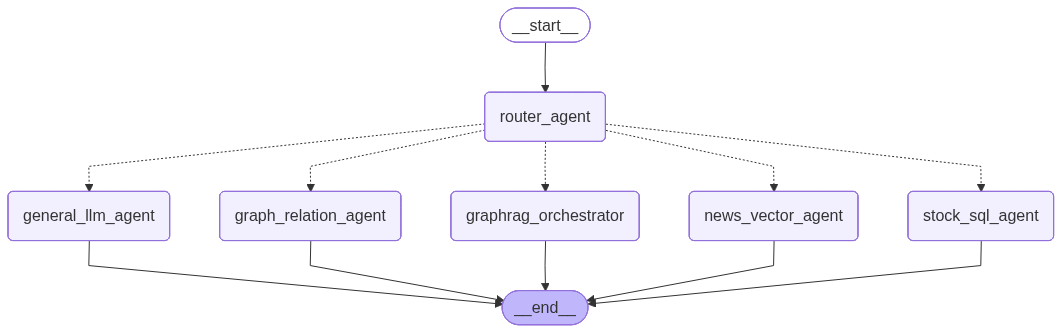

In [22]:
def show_graph(compiled_graph, title: str = "Graph") -> None:
    """
    LangGraph 그래프를 그림으로 보여준다.
    draw_mermaid_png()가 환경 문제로 실패하면 mermaid 텍스트를 출력한다.
    """
    print(f"\n===== {title} =====")
    try:
        from IPython.display import Image, display
        display(Image(compiled_graph.get_graph().draw_mermaid_png()))
    except Exception as e:
        print("PNG 그래프 표시 실패. Mermaid 텍스트로 대체합니다.")
        print(f"원인: {e}")
        print(compiled_graph.get_graph().draw_mermaid())


show_graph(app, "Main Routing Graph")



# 13. 각 Agent 단독 Graph 출력 확인


===== Single Agent Graph - PostgreSQL NL2SQL Agent =====


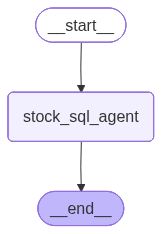


===== Single Agent Graph - pgvector RAG Agent =====


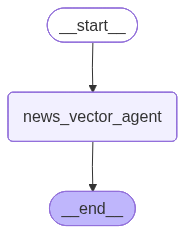


===== Single Agent Graph - Neo4j Graph Agent =====


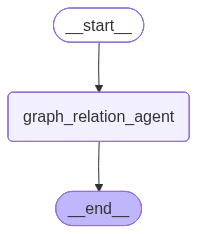


===== Single Agent Graph - General LLM Agent =====


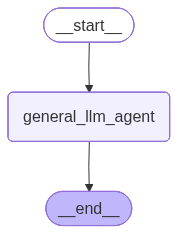


===== Single Agent Graph - GraphRAG Orchestrator =====


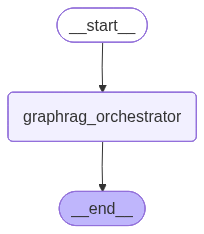

In [24]:
def build_single_agent_graph(node_name: str, node_func):
    """각 Agent가 하나의 node로 동작한다는 것을 보여주기 위한 단독 그래프."""
    g = StateGraph(ChatState)
    g.add_node(node_name, node_func)
    g.add_edge(START, node_name)
    g.add_edge(node_name, END)
    return g.compile(checkpointer=InMemorySaver())


single_stock_graph = build_single_agent_graph("stock_sql_agent", stock_sql_agent)
single_news_graph = build_single_agent_graph("news_vector_agent", news_vector_agent)
single_relation_graph = build_single_agent_graph("graph_relation_agent", graph_relation_agent)
single_general_graph = build_single_agent_graph("general_llm_agent", general_llm_agent)
single_graphrag_graph = build_single_agent_graph("graphrag_orchestrator", graphrag_orchestrator)

show_graph(single_stock_graph, "Single Agent Graph - PostgreSQL NL2SQL Agent")
show_graph(single_news_graph, "Single Agent Graph - pgvector RAG Agent")
show_graph(single_relation_graph, "Single Agent Graph - Neo4j Graph Agent")
show_graph(single_general_graph, "Single Agent Graph - General LLM Agent")
show_graph(single_graphrag_graph, "Single Agent Graph - GraphRAG Orchestrator")



# 14. GraphRAG 내부 개념 Graph 출력 확인


===== GraphRAG Internal Concept Graph =====


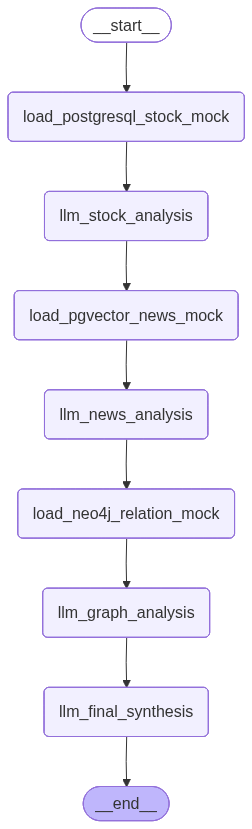

In [25]:
def passthrough_node(state: ChatState) -> ChatState:
    """GraphRAG 내부 흐름 그림용 dummy node. 실제 실행 목적이 아니라 구조 설명용이다."""
    return state


graphrag_internal = StateGraph(ChatState)
graphrag_internal.add_node("load_postgresql_stock_mock", passthrough_node)
graphrag_internal.add_node("llm_stock_analysis", passthrough_node)
graphrag_internal.add_node("load_pgvector_news_mock", passthrough_node)
graphrag_internal.add_node("llm_news_analysis", passthrough_node)
graphrag_internal.add_node("load_neo4j_relation_mock", passthrough_node)
graphrag_internal.add_node("llm_graph_analysis", passthrough_node)
graphrag_internal.add_node("llm_final_synthesis", passthrough_node)

graphrag_internal.add_edge(START, "load_postgresql_stock_mock")
graphrag_internal.add_edge("load_postgresql_stock_mock", "llm_stock_analysis")
graphrag_internal.add_edge("llm_stock_analysis", "load_pgvector_news_mock")
graphrag_internal.add_edge("load_pgvector_news_mock", "llm_news_analysis")
graphrag_internal.add_edge("llm_news_analysis", "load_neo4j_relation_mock")
graphrag_internal.add_edge("load_neo4j_relation_mock", "llm_graph_analysis")
graphrag_internal.add_edge("llm_graph_analysis", "llm_final_synthesis")
graphrag_internal.add_edge("llm_final_synthesis", END)

graphrag_internal_app = graphrag_internal.compile(checkpointer=InMemorySaver())
show_graph(graphrag_internal_app, "GraphRAG Internal Concept Graph")



# 15. 단일 질문 예제



In [31]:
# 흐름 정리:
# 사용자 질문
# → Router Agent
# → 선택된 Agent
# → mock_data 참조
# → OpenAI LLM 답변 생성
# → route / 최종답변 / 중간결과 출력

# 함수 정의만 하는 셀
# 질문 1개를 LangGraph 멀티 에이전트 그래프에 넣어서 실행하는 함수 >> run_one()

def run_one(question: str, thread_id: str = "demo-thread") -> ChatState:
    """
    question  : 사용자가 입력한 질문
    thread_id : LangGraph checkpointer가 대화 흐름을 구분하기 위한 ID

    이 함수는 다음을 수행한다.
    1. 사용자 질문을 ChatState 형태로 만든다.
    2. app.invoke()로 LangGraph 전체 그래프를 실행한다.
    3. Router가 선택한 route를 출력한다.
    4. 최종 답변을 출력한다.
    5. 각 Agent가 남긴 중간 결과(agent_outputs)를 출력한다.
    6. 전체 실행 결과 State를 반환한다.
    """

    print("\n" + "=" * 90)
    print(f"질문: {question}")

    # LangGraph에 넣을 최초 입력 State
    input_state: ChatState = {
        "messages": [HumanMessage(content=question)],  # LangGraph 메시지 형식
        "user_question": question,                     # 사용자 원문 질문
        "route": "",                                  # Router가 나중에 채움
        "agent_outputs": {},                          # Agent 중간 결과 저장 공간
        "final_answer": "",                           # 최종 답변 저장 공간
    }

    # thread_id는 LangGraph checkpointer가 실행 세션을 구분하는 값
    config = {"configurable": {"thread_id": thread_id}}

    # 여기서 실제 LangGraph 실행
    # START → router_agent → 선택된 agent → END 흐름이 수행됨
    result = app.invoke(input_state, config=config)

    # Router가 선택한 route 출력
    print("\n[선택 route]")
    print(result.get("route"))

    # 최종 사용자 응답 출력
    print("\n[최종 답변]")
    print(result.get("final_answer"))

    # 어떤 Agent들이 실행 결과를 남겼는지 확인
    print("\n[agent_outputs keys]")
    print(list(result.get("agent_outputs", {}).keys()))

    # Agent별 상세 중간 결과 출력
    print("\n[agent_outputs 상세]")
    print(json.dumps(result.get("agent_outputs", {}), ensure_ascii=False, indent=2))

    # 전체 실행 결과 State 반환
    return result

In [32]:
print("run_one 함수 정의 완료")
print("run_one callable:", callable(run_one))
print("app exists:", "app" in globals())

run_one 함수 정의 완료
run_one callable: True
app exists: True


In [42]:
# stock_sql_agent
# result = run_one("애플 최근 주가를 알려줘", thread_id="demo-thread-1")

# news_vector_agent
# result = run_one("애플 관련 뉴스를 알려줘", thread_id="demo-thread-1")

# graph_relation_agent
# result = run_one("애플과 엔비디아는 어떤 관계야?", thread_id="demo-thread-1")

# general_llm_agent
# result = run_one("인생에서 워라벨은 중요한가?", thread_id="demo-thread-1")

# graphrag_orchestrator
result = run_one("애플 주가, 최근 뉴스, TSMC와의 관계를 종합해서 설명해줘", thread_id="demo-thread-1")



질문: 애플 주가, 최근 뉴스, TSMC와의 관계를 종합해서 설명해줘
[router_agent] question = 애플 주가, 최근 뉴스, TSMC와의 관계를 종합해서 설명해줘
[router_agent] raw route = graphrag
[router_agent] normalized route = graphrag

[선택 route]
graphrag

[최종 답변]
현재 제공된 정보는 모두 mock 데이터 기반의 시연 결과임을 명확히 하며, 이를 종합하여 애플의 주가, 최근 뉴스, TSMC와의 관계를 다음과 같이 정리할 수 있습니다.

**주가 관점**  
애플의 최근 주가는 약 198.42달러로 안정적인 상승세를 보이고 있으며, 시장 기대와 긍정적인 뉴스에 힘입어 강세를 유지하고 있습니다. 거래량도 안정적이며, 전반적으로 투자자들의 신뢰가 유지되고 있음을 시사합니다.

**뉴스 관점**  
최근 뉴스에서는 애플이 온디바이스 AI 기능 강화와 신제품 출시, 서비스 확장에 집중하고 있다는 점이 부각되고 있습니다. 이는 사용자 경험 향상과 기술 혁신을 통해 시장 경쟁력을 높이려는 전략의 일환입니다.

**관계/이벤트 관점**  
애플과 TSMC는 반도체 공급망에서 긴밀히 협력하고 있으며, TSMC는 첨단 공정 용량을 조정하여 AI 칩 수요에 대응하고 있습니다. 애플은 TSMC의 첨단 노드 생산 능력을 활용하여 AI 관련 제품 개발에 박차를 가하고 있으며, 이 협력은 글로벌 AI 생태계 성장과 밀접한 관련이 있습니다.

**종합 인사이트**  
이 세 가지 관점은 모두 애플의 기술 혁신과 공급망 안정성, 그리고 시장 기대가 서로 긍정적으로 연결되어 있음을 보여줍니다. 애플의 주가 상승은 최신 기술 개발과 TSMC와의 긴밀한 협력, 그리고 AI 확장 전략이 결합된 결과로 볼 수 있으며, 이는 글로벌 기술 산업의 전반적인 긍정적 분위기를 반영하는 것으로 해석됩니다.

단, 이 모든 내용은 현재 mock 데이터 기반의 시연 결과임을 유념하시기 바랍니다.

[age

# 16. 다수 질문 예제



In [43]:
MULTI_QUESTIONS = [
    "1) 애플 최근 주가 알려줘",
    "2) 엔비디아 관련 최근 뉴스 요약해줘",
    "3) TSMC와 엔비디아는 어떤 관계야?",
    "4) LangGraph가 뭐야?",
    "5) 엔비디아 주가, 최근 뉴스, TSMC와의 관계를 종합해서 설명해줘",
]

results = []
for idx, q in enumerate(MULTI_QUESTIONS, start=1):
    results.append(run_one(q, thread_id=f"demo-thread-{idx}"))




질문: 1) 애플 최근 주가 알려줘
[router_agent] question = 1) 애플 최근 주가 알려줘
[router_agent] raw route = stock_sql
[router_agent] normalized route = stock_sql

[선택 route]
stock_sql

[최종 답변]
현재 애플(AAPL)의 최근 주가는 2026년 6월 12일 기준으로 198.42 USD입니다. 최근 5거래일 동안 완만한 반등 흐름을 보이고 있으며, 오늘은 1.36 USD(0.69%) 상승하였습니다.

[agent_outputs keys]
['router', 'stock_sql_agent', 'news_vector_agent', 'graphrag_orchestrator']

[agent_outputs 상세]
{
  "router": {
    "raw_route": "stock_sql",
    "normalized_route": "stock_sql"
  },
  "stock_sql_agent": {
    "context_file": "postgresql_stock_mock.json",
    "llm_augmented": true,
    "context_summary": "PostgreSQL mock 조회 결과를 LLM context로 전달함",
    "answer": "현재 애플(AAPL)의 최근 주가는 2026년 6월 12일 기준으로 198.42 USD입니다. 최근 5거래일 동안 완만한 반등 흐름을 보이고 있으며, 오늘은 1.36 USD(0.69%) 상승하였습니다."
  },
  "news_vector_agent": {
    "context_file": "pgvector_news_mock.json",
    "llm_augmented": true,
    "context_summary": "pgvector mock 검색 결과를 LLM context로 전달함",
    "answer": "최근 애플은 기기 내 AI 기능 확장에 집중하고 있다

# 17. 요점 설명



In [44]:
print("""
시연 흐름 요약
1. 사용자가 질문을 입력한다.
2. router_agent가 OpenAI LLM으로 질문 의도를 분류한다.
3. stock/news/graph 계열이면 실제 DB 대신 mock_data/*.json 파일을 읽는다. (현재 단계에서는...)
4. 읽은 mock 결과를 context로 LLM에 전달한다.
5. LLM이 context 기반으로 최종 답변을 생성한다.
6. general_llm route는 mock 파일 없이 OpenAI LLM이 직접 답변한다.
7. graphrag route는 stock/news/graph context를 모두 읽고, 중간 분석 후 종합 답변을 생성한다.
8. 향후, 실시간 인터넷 검색 Agent를 추가하도록 한다.
""")



시연 흐름 요약
1. 사용자가 질문을 입력한다.
2. router_agent가 OpenAI LLM으로 질문 의도를 분류한다.
3. stock/news/graph 계열이면 실제 DB 대신 mock_data/*.json 파일을 읽는다. (현재 단계에서는...)
4. 읽은 mock 결과를 context로 LLM에 전달한다.
5. LLM이 context 기반으로 최종 답변을 생성한다.
6. general_llm route는 mock 파일 없이 OpenAI LLM이 직접 답변한다.
7. graphrag route는 stock/news/graph context를 모두 읽고, 중간 분석 후 종합 답변을 생성한다.
8. 향후, 실시간 인터넷 검색 Agent를 추가하도록 한다.

